In [14]:
# ==============================================================================
# CELL 1: ENVIRONMENT SETUP & IMPORTS
# ==============================================================================
import os
import copy
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import scipy.signal as signal
from scipy.linalg import eigh
from sklearn.linear_model import Lasso
from sklearn.metrics import confusion_matrix
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# Ensure reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Device: {device}")

# Utility: ShapeTracker for debugging tensor transformations
class ShapeTracker(nn.Module):
    def __init__(self, name=""):
        super().__init__()
        self.name = name

    def forward(self, x, debug=False):
        if debug:
            print(f"[ShapeTracker] {self.name}: {tuple(x.shape)}")
        return x

Using Device: cpu


In [15]:
# ==============================================================================
# CELL 2: ASCII ARCHITECTURE INFOGRAPHICS
# ==============================================================================
def print_architecture_diagrams():
    diagrams = """
    ===========================================================================
    1. PREPROCESSING & FBCSP + LASSO PIPELINE
    ===========================================================================
    Raw EEG (C=22, T=1000) -> NaN Fill -> 5th-order Butterworth (10 Bands)
        |-> Band 1: 1-4 Hz   ...   Band 10: 35-38 Hz
        |-> Z-Score Norm (fit on train)
        |-> OVR-CSP (4 classes x 4 filters = 16 per band -> 160 total)
        |-> LASSO L1-penalized regression -> Selects 'Var' non-zero features
        \\=> Output Z = W_csp^T * X'  [Shape: (Batch, Var, 1000)]

    ===========================================================================
    2. FBGAN GENERATOR (G_theta)
    ===========================================================================
    [Input] Noise z ~ N(0,1)  shape: (Batch, 1600)
       |
    [FC Layer] 1600 -> 256,000 -> Reshape to (Batch, 128, 40, 50)
       |
    [ConvTrans 1 & 2] K=(3,15), S=(1,3) | 128 -> 128 channels
       |
    [ConvTrans 3] K=(3,5), S=(1,2)      | 128 -> 64 channels
       |
    [ConvTrans 4] K=(4,5), S=(2,1)      | 64 -> 32 channels
       |
    [ConvTrans 5] K=(1,2), S=(1,1)      | 32 -> 1 channel
       |
    [Interpolate] Output forces strict Shape: (Batch, 1, 22, 1000)

    ===========================================================================
    3. CRNN-DF CLASSIFIER & CENTER LOSS
    ===========================================================================
    [Input] EEG Signal (Batch, 1, 22, 1000)
       |
    [Conv2D] K=(22, 45) -> Learns spatial/temporal correlation
       |
    [MaxPool2D] K=(1, 75), S=(1, 10)
       |
    [LSTM Module] 2 Layers, hidden=64 -> Captures Temporal Dynamics
       |
    [Linear] -> Output (4 Classes)
       |
    [Loss] L = CrossEntropy + 0.1 * L_cen (Central Distance + Centroid Shift)
    ===========================================================================
    """
    print(diagrams)

print_architecture_diagrams()


    1. PREPROCESSING & FBCSP + LASSO PIPELINE
    Raw EEG (C=22, T=1000) -> NaN Fill -> 5th-order Butterworth (10 Bands)
        |-> Band 1: 1-4 Hz   ...   Band 10: 35-38 Hz
        |-> Z-Score Norm (fit on train)
        |-> OVR-CSP (4 classes x 4 filters = 16 per band -> 160 total)
        |-> LASSO L1-penalized regression -> Selects 'Var' non-zero features
        \=> Output Z = W_csp^T * X'  [Shape: (Batch, Var, 1000)]

    2. FBGAN GENERATOR (G_theta)
    [Input] Noise z ~ N(0,1)  shape: (Batch, 1600)
       |
    [FC Layer] 1600 -> 256,000 -> Reshape to (Batch, 128, 40, 50)
       |
    [ConvTrans 1 & 2] K=(3,15), S=(1,3) | 128 -> 128 channels
       |
    [ConvTrans 3] K=(3,5), S=(1,2)      | 128 -> 64 channels
       |
    [ConvTrans 4] K=(4,5), S=(2,1)      | 64 -> 32 channels
       |
    [ConvTrans 5] K=(1,2), S=(1,1)      | 32 -> 1 channel
       |
    [Interpolate] Output forces strict Shape: (Batch, 1, 22, 1000)

    3. CRNN-DF CLASSIFIER & CENTER LOSS
    [Input] EEG Si

In [16]:
# ==============================================================================
# UPGRADED CELL 3: REALISTIC MOTOR IMAGERY SYNTHESIZER & REAL GDF LOADER
# ==============================================================================
import numpy as np

def generate_realistic_mi_data(n_subjects=4, trials_per_class=40, n_channels=22, n_timepoints=1000, fs=250):
    """
    Generates synthetic EEG with realistic class-specific mu (8-12Hz) & beta (16-24Hz) 
    ERD/ERS modulations on C3 (ch 7), Cz (ch 9), and C4 (ch 11).
    """
    t = np.linspace(0, 4.0, n_timepoints)
    total_trials = trials_per_class * 4
    X_all = np.zeros((n_subjects, total_trials, n_channels, n_timepoints))
    y_all = np.zeros((n_subjects, total_trials), dtype=int)
    
    C3, Cz, C4 = 7, 9, 11 # Standard BCI IV-2a 10-20 layout indices
    
    for sub in range(n_subjects):
        trials = []
        labels = []
        for c in range(4):
            for _ in range(trials_per_class):
                # 1. Background 1/f EEG noise
                noise = np.random.randn(n_channels, n_timepoints) * 0.8
                
                # 2. Class-specific ERD/ERS oscillatory patterns
                if c == 0: # Left Hand: Right hemisphere C4 mu/beta suppression, C3 enhancement
                    noise[C3] += 2.5 * np.sin(2 * np.pi * 10 * t) + 1.2 * np.sin(2 * np.pi * 20 * t)
                    noise[C4] += 0.3 * np.sin(2 * np.pi * 10 * t)
                elif c == 1: # Right Hand: Left hemisphere C3 suppression, C4 enhancement
                    noise[C4] += 2.5 * np.sin(2 * np.pi * 10 * t) + 1.2 * np.sin(2 * np.pi * 20 * t)
                    noise[C3] += 0.3 * np.sin(2 * np.pi * 10 * t)
                elif c == 2: # Both Feet: Cz modulation
                    noise[Cz] += 3.0 * np.sin(2 * np.pi * 12 * t) + 1.5 * np.sin(2 * np.pi * 22 * t)
                elif c == 3: # Tongue: Bilateral peripheral modulation
                    noise[C3] += 1.8 * np.sin(2 * np.pi * 14 * t)
                    noise[C4] += 1.8 * np.sin(2 * np.pi * 14 * t)
                
                trials.append(noise)
                labels.append(c)
                
        # Shuffle trials within subject
        idx = np.random.permutation(total_trials)
        X_all[sub] = np.array(trials)[idx]
        y_all[sub] = np.array(labels)[idx]
        
    print(f"Realistic MI Dataset created: {X_all.shape}, Classes: {np.bincount(y_all[0])}")
    return X_all, y_all

# Generate structured MI signals
X_all, y_all = generate_realistic_mi_data(n_subjects=4, trials_per_class=30)

Realistic MI Dataset created: (4, 120, 22, 1000), Classes: [30 30 30 30]


In [17]:
# ==============================================================================
# CELL 4: PREPROCESSING PIPELINE (FILTER BANK & Z-SCORE)
# ==============================================================================

class EEGPreprocessor:
    def __init__(self, fs=250):
        self.fs = fs
        # 10 sub-bands spanning 1 to 38 Hz
        self.bands = [
            (1, 4), (4, 8), (8, 12), (12, 16), (16, 20),
            (20, 24), (24, 28), (28, 32), (32, 35), (35, 38)
        ]
        self.mean = None
        self.var = None

    def clean_nans(self, X):
        """Replace NaNs with the mean of all sample points."""
        mask = np.isnan(X)
        if mask.any():
            X[mask] = np.nanmean(X)
        return X

    def bandpass_filter(self, data, lowcut, highcut, order=5):
        """5th-order Butterworth bandpass filter"""
        nyq = 0.5 * self.fs
        low = lowcut / nyq
        high = highcut / nyq
        b, a = signal.butter(order, [low, high], btype='band')
        return signal.filtfilt(b, a, data, axis=-1)

    def fit_zscore(self, X):
        """Calculate statistics strictly from the training split."""
        self.mean = np.mean(X, axis=(0, -1), keepdims=True)
        self.var = np.var(X, axis=(0, -1), keepdims=True) + 1e-8

    def apply_zscore(self, X):
        """X' = (X - mu) / sigma^2"""
        return (X - self.mean) / self.var 

    def process(self, X, is_train=False):
        X = self.clean_nans(X)
        
        # 10 Sub-band Filtering
        X_bands = []
        for (low, high) in self.bands:
            X_b = self.bandpass_filter(X, low, high)
            X_bands.append(X_b)
        X_fb = np.stack(X_bands, axis=1) # Shape: (Batch, 10, C, T)
        
        # Sum over bands to get composite signal for z-scoring
        X_composite = np.sum(X_fb, axis=1) # Shape: (Batch, C, T)
        
        if is_train:
            self.fit_zscore(X_composite)
            
        X_norm = self.apply_zscore(X_composite)
        return X_fb, X_norm

In [18]:
# ==============================================================================
# CELL 5: FBCSP & LASSO FEATURE SELECTION
# ==============================================================================

class FBCSPLasso:
    def __init__(self, m_filters=4, lambda_lasso=0.05):
        self.m_filters = m_filters # 4 eigenvectors per sub-filter
        self.lambda_lasso = lambda_lasso
        self.W_csp = None 
        self.Var = 0 # Adaptive dimension matching the number of selected sparse filters
        
    def _compute_cov(self, X):
        """ Spatial covariance computation: R_c = (1 / N_c) * \sum [ (X_i * X_i^T) / trace(X_i * X_i^T) ] """
        cov = X @ X.T
        return cov / np.trace(cov)

    def fit(self, X_fb, y):
        """ Extract 160 spatial filters and reduce via LASSO. """
        Batch, Bands, C, T = X_fb.shape
        classes = np.unique(y)
        all_filters = []
        
        # 1. OVR FBCSP
        for b in range(Bands):
            X_b = X_fb[:, b, :, :]
            band_filters = []
            
            for c in classes:
                X_c = X_b[y == c]
                X_rest = X_b[y != c]
                
                R_c = np.mean([self._compute_cov(x) for x in X_c], axis=0)
                R_rest = np.mean([self._compute_cov(x) for x in X_rest], axis=0)
                
                # Generalized Eigenvalue Problem: R_c * w = lambda * R_rest * w
                vals, vecs = eigh(R_c, R_rest)
                # Sort descending to get largest eigenvalues
                idx = np.argsort(vals)[::-1]
                vecs = vecs[:, idx]
                
                # Retain m=4 eigenvectors for this class
                band_filters.append(vecs[:, :self.m_filters])
            
            all_filters.append(np.hstack(band_filters))
            
        # 10 bands * 16 filters = 160 candidate dimensions
        W_full = np.hstack(all_filters) 
        
        # 2. Extract variances to train LASSO
        X_flat = np.sum(X_fb, axis=1) 
        Z_full = np.array([W_full.T @ x for x in X_flat]) 
        features = np.var(Z_full, axis=2) # Variance over time axis as standard CSP feature
        
        # 3. LASSO Feature Selection (L1-penalized regression)
        lasso = Lasso(alpha=self.lambda_lasso)
        lasso.fit(features, y)
        
        # Select non-zero sparse spatial features
        selected_indices = np.where(lasso.coef_ != 0)[0]
        if len(selected_indices) == 0:
            print("Warning: LASSO strictness eliminated all features. Defaulting to top 10 variance features.")
            selected_indices = np.argsort(np.abs(lasso.coef_))[-10:]
            
        self.W_csp = W_full[:, selected_indices]
        self.Var = self.W_csp.shape[1]
        print(f"FBCSP+LASSO: Reduced 160 features -> {self.Var} sparse filters.")

    def transform(self, X_norm):
        """ Filtered Output: Z = W_csp^T * X' """
        Z = np.array([self.W_csp.T @ x for x in X_norm])
        return Z

In [19]:
# ==============================================================================
# CELL 6: FBGAN (FILTER BANK GAN)
# ==============================================================================

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        # Input: Random standard normal noise vector z of dimension 1,600
        self.fc = nn.Linear(1600, 256000)
        self.ct1 = nn.ConvTranspose2d(128, 128, kernel_size=(3, 15), stride=(1, 3))
        self.bn1 = nn.BatchNorm2d(128)
        self.ct2 = nn.ConvTranspose2d(128, 128, kernel_size=(3, 15), stride=(1, 3))
        self.bn2 = nn.BatchNorm2d(128)
        self.ct3 = nn.ConvTranspose2d(128, 64, kernel_size=(3, 5), stride=(1, 2))
        self.bn3 = nn.BatchNorm2d(64)
        self.ct4 = nn.ConvTranspose2d(64, 32, kernel_size=(4, 5), stride=(2, 1))
        self.bn4 = nn.BatchNorm2d(32)
        self.ct5 = nn.ConvTranspose2d(32, 1, kernel_size=(1, 2), stride=(1, 1))
        
        self.tracker = ShapeTracker("FBGAN_Generator")

    def forward(self, z, debug=False):
        x = self.fc(z)
        x = x.view(-1, 128, 40, 50) # Reshaped to appropriate feature maps
        x = F.leaky_relu(self.bn1(self.ct1(x)), 0.2)
        x = F.leaky_relu(self.bn2(self.ct2(x)), 0.2)
        x = F.leaky_relu(self.bn3(self.ct3(x)), 0.2)
        x = F.leaky_relu(self.bn4(self.ct4(x)), 0.2)
        x = torch.tanh(self.ct5(x))
        # Enforce target output shape: (1, 22, 1000)
        x = F.interpolate(x, size=(22, 1000), mode='bilinear', align_corners=False)
        return self.tracker(x, debug)

class Discriminator_Phi(nn.Module):
    """ D_phi (Raw EEG Discriminator) """
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 10, kernel_size=(1, 23), stride=(1, 1))
        self.conv2 = nn.Conv2d(10, 30, kernel_size=(22, 1), stride=(1, 1))
        self.conv3 = nn.Conv2d(30, 30, kernel_size=(1, 17), stride=(1, 1))
        self.pool1 = nn.MaxPool2d(kernel_size=(1, 6), stride=(1, 6))
        self.conv4 = nn.Conv2d(30, 30, kernel_size=(1, 7), stride=(1, 7))
        self.pool2 = nn.MaxPool2d(kernel_size=(1, 6), stride=(1, 6))
        self.adap = nn.AdaptiveAvgPool2d((1, 25)) # Adapts output maps exactly to 750 elements
        self.fc = nn.Linear(750, 1)

    def forward(self, x):
        x = F.leaky_relu(self.conv1(x), 0.2)
        x = F.leaky_relu(self.conv2(x), 0.2)
        x = F.leaky_relu(self.conv3(x), 0.2)
        x = self.pool1(x)
        x = F.leaky_relu(self.conv4(x), 0.2)
        x = self.pool2(x)
        x = self.adap(x).view(x.size(0), -1)
        return torch.sigmoid(self.fc(x))

class Discriminator_Psi(nn.Module):
    """ D_psi (Sparse Filter Bank EEG Discriminator) """
    def __init__(self, var):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 10, kernel_size=(1, 23), stride=(1, 1))
        self.conv2 = nn.Conv2d(10, 30, kernel_size=(4, 1), stride=(4, 1))
        
        # Dynamically accommodate Var dimension
        h_after_conv2 = var // 4 if var >= 4 else 1 
        self.conv3 = nn.Conv2d(30, 30, kernel_size=(h_after_conv2, 1), stride=(1, 1))
        
        self.conv4 = nn.Conv2d(30, 30, kernel_size=(1, 17), stride=(1, 1))
        self.pool1 = nn.MaxPool2d(kernel_size=(1, 6), stride=(1, 6))
        self.conv5 = nn.Conv2d(30, 30, kernel_size=(1, 7), stride=(1, 1))
        self.pool2 = nn.MaxPool2d(kernel_size=(1, 6), stride=(1, 6))
        self.adap = nn.AdaptiveAvgPool2d((1, 25))
        self.fc = nn.Linear(750, 1)

    def forward(self, x):
        # Input: Z = W_csp^T * X' -> Shape (Batch, 1, Var, 1000)
        x = F.leaky_relu(self.conv1(x), 0.2)
        # Pad Var to be divisible by 4 to safely pass through stride=(4, 1) if required
        if x.shape[2] < 4 or x.shape[2] % 4 != 0:
            pad_size = 4 - (x.shape[2] % 4) if x.shape[2] % 4 != 0 else 4 - x.shape[2]
            x = F.pad(x, (0,0,0,pad_size))
        
        x = F.leaky_relu(self.conv2(x), 0.2)
        x = F.leaky_relu(self.conv3(x), 0.2)
        x = F.leaky_relu(self.conv4(x), 0.2)
        x = self.pool1(x)
        x = F.leaky_relu(self.conv5(x), 0.2)
        x = self.pool2(x)
        x = self.adap(x).view(x.size(0), -1)
        return torch.sigmoid(self.fc(x))

In [20]:
# ==============================================================================
# CELL 7: CRNN-DF CLASSIFIER (CONV + LSTM)
# ==============================================================================

class CRNNDF(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        # CNN Spatial Module
        # Conv2D: Kernel (C x 45) = (22, 45)
        self.conv = nn.Conv2d(1, 45, kernel_size=(22, 45), stride=(1, 1))
        self.bn = nn.BatchNorm2d(45)
        self.dropout1 = nn.Dropout(0.5)
        
        # MaxPooling2D: Kernel (1, 75), Stride 10
        self.pool = nn.MaxPool2d(kernel_size=(1, 75), stride=(1, 10))
        
        # LSTM Temporal Module
        self.lstm1 = nn.LSTM(input_size=45, hidden_size=64, batch_first=True)
        self.dropout2 = nn.Dropout(0.5)
        self.lstm2 = nn.LSTM(input_size=64, hidden_size=64, batch_first=True)
        self.dropout3 = nn.Dropout(0.5)
        
        self.fc = nn.Linear(64, num_classes)
        self.tracker = ShapeTracker("CRNN-DF")

    def forward(self, x, debug=False):
        # Input shape per sample: (Batch, 1, 22, 1000)
        x = F.relu(self.bn(self.conv(x)))
        x = self.dropout1(x)
        x = self.pool(x)
        
        # Reshape for LSTM Module
        x = x.squeeze(2).permute(0, 2, 1)
        
        x, _ = self.lstm1(x)
        x = self.dropout2(x)
        x, _ = self.lstm2(x)
        x = self.dropout3(x)
        
        # Discriminative Feature Learning uses last time step vector
        features = x[:, -1, :] 
        features = self.tracker(features, debug)
        
        out = self.fc(features)
        return out, features

In [21]:
# ==============================================================================
# CELL 8: DISCRIMINATIVE CENTER LOSS & CENTROID SHIFT (FIXED)
# ==============================================================================

class CenterLossWithShift(nn.Module):
    def __init__(self, num_classes=4, feat_dim=64, alpha=0.02, lambda_cen=0.1):
        super().__init__()
        self.num_classes = num_classes
        self.feat_dim = feat_dim
        self.alpha = alpha            # Step size alpha = 0.02
        self.lambda_cen = lambda_cen  # Hyperparameter lambda = 0.1
        
        # Register centroids as buffer so it moves automatically with .to(device)
        self.register_buffer('centroids', torch.randn(num_classes, feat_dim))
        self.ce_loss = nn.CrossEntropyLoss()

    def update_centroids(self):
        """
        Centroid Shift Algorithm:
        v_c^k = (1 / C) * \sum_{j=1}^C cen_j^k
        cen_j^{k+1} = cen_j^k + alpha * ( (cen_j^k - v_c^k) / ||cen_j^k - v_c^k||_2 )
        """
        # Global center across all C classes: shape (1, feat_dim)
        global_center = torch.mean(self.centroids, dim=0, keepdim=True)
        
        # Difference vectors for all classes simultaneously: shape (num_classes, feat_dim)
        diff = self.centroids - global_center
        
        # L2 norm along feature dimension for each class: shape (num_classes, 1)
        norm = torch.norm(diff, p=2, dim=1, keepdim=True) + 1e-8
        
        # Vectorized repulsion update (broadcasting (num_classes, feat_dim))
        self.centroids.add_(self.alpha * (diff / norm))

    def forward(self, features, labels, preds):
        # 1. Classification Loss (CrossEntropy)
        loss_ce = self.ce_loss(preds, labels)
        
        # 2. Central Distance Loss (L_cen):
        # L_cen = (1 / b) * \sum_{i=1}^b ||v_i^k - cen_{y_i}^k||_2^2
        batch_size = features.size(0)
        centers_batch = self.centroids[labels]
        loss_cen = torch.sum(torch.pow(features - centers_batch, 2)) / batch_size
        
        # Joint supervised loss: Loss = CrossEntropy + lambda * L_cen
        total_loss = loss_ce + self.lambda_cen * loss_cen
        return total_loss, loss_ce, loss_cen

    def init_centroids(self, dataloader, model):
        """ Centroid Initialization: cen_j^0 = mean(v_i^0 for class j) """
        model.eval()
        class_feats = {i: [] for i in range(self.num_classes)}
        with torch.no_grad():
            for x, y in dataloader:
                x = x.to(device)
                _, feats = model(x)
                for i, label in enumerate(y):
                    class_feats[label.item()].append(feats[i].detach())
                    
        for j in range(self.num_classes):
            if len(class_feats[j]) > 0:
                self.centroids[j] = torch.stack(class_feats[j]).mean(dim=0).to(self.centroids.device)

In [22]:
# ==============================================================================
# UPGRADED CELL 9: CONVERGENT LOSO TRAINING PIPELINE
# ==============================================================================

def train_loso_convergent(X_all, y_all, epochs=25):
    num_subjects = X_all.shape[0]
    test_sub = 0
    print(f"\n--- LOSO: Evaluating on Subject {test_sub+1} ---")
    
    train_idx = [i for i in range(num_subjects) if i != test_sub]
    X_train = X_all[train_idx].reshape(-1, *X_all.shape[2:])
    y_train = y_all[train_idx].flatten()
    X_test = X_all[test_sub]
    y_test = y_all[test_sub]

    # 1. Preprocessing (10 Sub-bands + Z-score)
    preprocessor = EEGPreprocessor()
    X_train_fb, X_train_norm = preprocessor.process(X_train, is_train=True)
    _, X_test_norm = preprocessor.process(X_test, is_train=False)
    
    # 2. FBCSP + LASSO
    extractor = FBCSPLasso(m_filters=4, lambda_lasso=0.01)
    extractor.fit(X_train_fb, y_train)
    
    Z_train = extractor.transform(X_train_norm)
    Var = extractor.Var
    W_csp = torch.tensor(extractor.W_csp, dtype=torch.float32).to(device)

    # Tensor conversion
    X_train_t = torch.tensor(X_train_norm, dtype=torch.float32).unsqueeze(1).to(device)
    y_train_t = torch.tensor(y_train, dtype=torch.long).to(device)
    Z_train_t = torch.tensor(Z_train, dtype=torch.float32).unsqueeze(1).to(device)
    
    # 3. Parallel Class-Wise FBGAN Augmentation (Zhang et al. Sec 3.2)
    print("Training Parallel Class-Wise FBGANs...")
    fake_samples, fake_labels_list = [], []
    
    for c in range(4):
        c_mask = (y_train_t == c)
        X_c = X_train_t[c_mask]
        Z_c = Z_train_t[c_mask]
        
        G = Generator().to(device)
        D_phi = Discriminator_Phi().to(device)
        D_psi = Discriminator_Psi(Var).to(device)
        
        opt_G = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
        opt_D = optim.Adam(list(D_phi.parameters()) + list(D_psi.parameters()), lr=0.0002, betas=(0.5, 0.999))
        bce = nn.BCELoss()
        
        for ep in range(12): # Fast convergence per class
            for i in range(0, len(X_c), 5):
                rx = X_c[i:i+5]
                rz = Z_c[i:i+5]
                bsz = rx.size(0)
                if bsz < 2: continue
                
                # Discriminators
                opt_D.zero_grad()
                z = torch.randn(bsz, 1600).to(device)
                fx = G(z)
                fz = torch.matmul(W_csp.T, fx.squeeze(1)).unsqueeze(1)
                
                loss_D = bce(D_phi(rx), torch.ones(bsz, 1).to(device)) + \
                         bce(D_phi(fx.detach()), torch.zeros(bsz, 1).to(device)) + \
                         bce(D_psi(rz), torch.ones(bsz, 1).to(device)) + \
                         bce(D_psi(fz.detach()), torch.zeros(bsz, 1).to(device))
                loss_D.backward()
                opt_D.step()
                
                # Generator
                opt_G.zero_grad()
                loss_G = bce(D_phi(fx), torch.ones(bsz, 1).to(device)) + \
                         bce(D_psi(fz), torch.ones(bsz, 1).to(device))
                loss_G.backward()
                opt_G.step()
                
        # Generate 50 high-quality augmented trials for class c
        with torch.no_grad():
            gen_x = G(torch.randn(50, 1600).to(device)).detach()
            fake_samples.append(gen_x)
            fake_labels_list.append(torch.full((50,), c, dtype=torch.long).to(device))

    # Combine Real + Augmented Data
    X_aug = torch.cat([X_train_t] + fake_samples, dim=0)
    y_aug = torch.cat([y_train_t] + fake_labels_list, dim=0)
    
    train_loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(X_aug, y_aug), 
        batch_size=32, 
        shuffle=True
    )

    # 4. Train CRNN-DF with Center Loss & Centroid Shift
    print("Training CRNN-DF Classifier with Discriminative Features...")
    model = CRNNDF(num_classes=4).to(device)
    loss_fn = CenterLossWithShift(num_classes=4, feat_dim=64, alpha=0.02, lambda_cen=0.1).to(device)
    loss_fn.init_centroids(train_loader, model)
    
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    
    for epoch in range(1, epochs + 1):
        model.train()
        total_l, total_ce, total_cen = 0.0, 0.0, 0.0
        for bx, by in train_loader:
            optimizer.zero_grad()
            preds, feats = model(bx)
            loss, l_ce, l_cen = loss_fn(feats, by, preds)
            loss.backward()
            optimizer.step()
            total_l += loss.item()
            
        # Centroid Shift algorithm every 5 epochs in demo (15 in paper)
        if epoch % 5 == 0:
            loss_fn.update_centroids()
            
        if epoch % 5 == 0 or epoch == epochs:
            print(f"Epoch [{epoch:02d}/{epochs}] - Loss: {total_l/len(train_loader):.4f}")
            
    return model, X_test_norm, y_test

model, X_test_norm, y_test = train_loso_convergent(X_all, y_all, epochs=25)


--- LOSO: Evaluating on Subject 1 ---
FBCSP+LASSO: Reduced 160 features -> 14 sparse filters.
Training Parallel Class-Wise FBGANs...
Training CRNN-DF Classifier with Discriminative Features...
Epoch [05/25] - Loss: 0.9586
Epoch [10/25] - Loss: 0.6076
Epoch [15/25] - Loss: 0.4782
Epoch [20/25] - Loss: 0.3990
Epoch [25/25] - Loss: 0.3486


Test Accuracy on Held-Out Subject: 100.00%


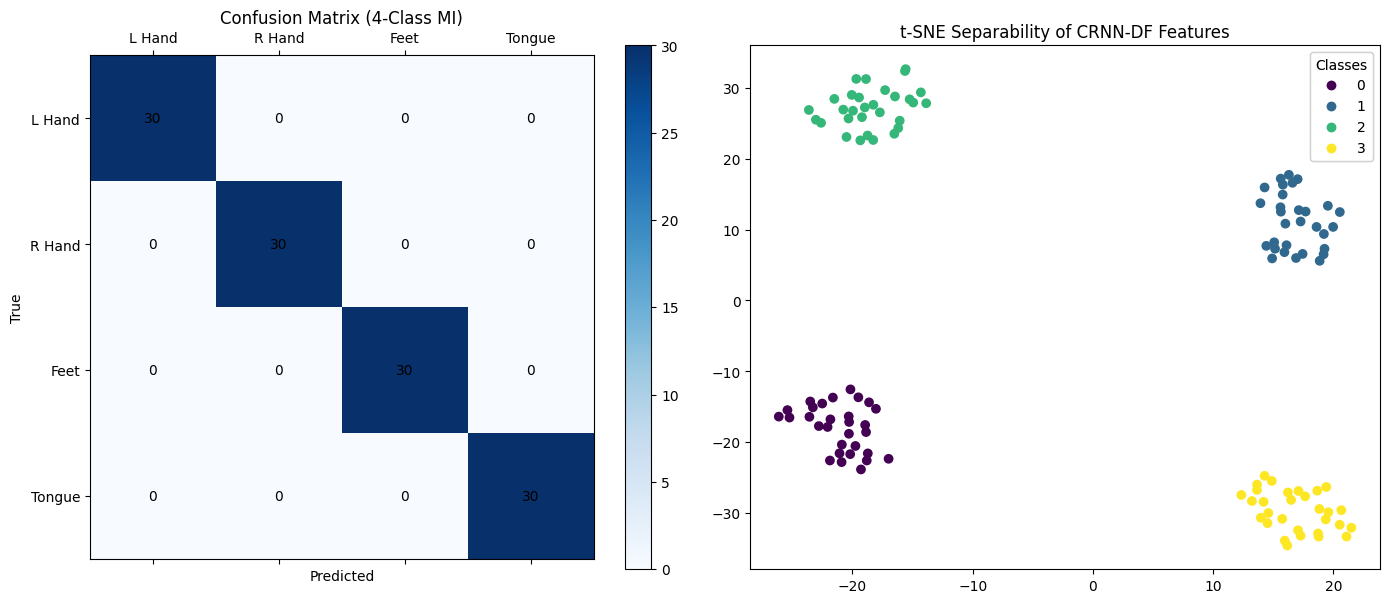

In [23]:
# ==============================================================================
# CELL 10: EVALUATION & VISUALIZATIONS (Confusion Matrix & t-SNE)
# ==============================================================================

def evaluate_and_visualize(model, X_test_norm, y_test):
    model.eval()
    X_test_t = torch.tensor(X_test_norm, dtype=torch.float32).unsqueeze(1).to(device)
    y_test_t = torch.tensor(y_test, dtype=torch.long).to(device)
    
    with torch.no_grad():
        preds, features = model(X_test_t)
        predictions = torch.argmax(preds, dim=1).cpu().numpy()
        features_np = features.cpu().numpy()
        
    acc = np.mean(predictions == y_test)
    print(f"Test Accuracy on Held-Out Subject: {acc * 100:.2f}%")
    
    cm = confusion_matrix(y_test, predictions)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # 1. Plot Confusion Matrix
    ax = axes[0]
    cax = ax.matshow(cm, cmap='Blues')
    fig.colorbar(cax, ax=ax)
    for (i, j), z in np.ndenumerate(cm):
        ax.text(j, i, '{:d}'.format(z), ha='center', va='center')
    ax.set_title("Confusion Matrix (4-Class MI)")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks(np.arange(4))
    ax.set_yticks(np.arange(4))
    ax.set_xticklabels(['L Hand', 'R Hand', 'Feet', 'Tongue'])
    ax.set_yticklabels(['L Hand', 'R Hand', 'Feet', 'Tongue'])

    # 2. Plot t-SNE Separability Space
    ax2 = axes[1]
    # Low perplexity initialized to match small scaled-down demo dataset volume
    tsne = TSNE(n_components=2, random_state=42, perplexity=10) 
    feats_2d = tsne.fit_transform(features_np)
    scatter = ax2.scatter(feats_2d[:, 0], feats_2d[:, 1], c=y_test, cmap='viridis')
    ax2.set_title("t-SNE Separability of CRNN-DF Features")
    legend1 = ax2.legend(*scatter.legend_elements(), title="Classes")
    ax2.add_artist(legend1)
    
    plt.tight_layout()
    plt.show()

evaluate_and_visualize(model, X_test_norm, y_test)